In [15]:
from dotenv import load_dotenv

load_dotenv()

True

LangChain 아이디를 입력합니다.


In [16]:
# Owner 지정
PROMPT_OWNER = "teddynote"

### 요약(Summarization)

문서 요약을 수행하는 방법에 대해 살펴보겠습니다.
아래는 튜토리얼의 주요 개요입니다. 

- stuff : 전체 문서 한 번에 요약
- Map-Reduce: 분할 요약 후 일괄 병합
- Map-Refine : 분할 요약 후 점진적인 병합
- Chain of Density: N번 반복 실행하며, 누락된 entity를 보완하며 요약 개선
- Clustering-Map-Refine : 문서의 chunk를 N개의 클러스터로 나누고, 각 클러스터에서 중심점에 가까운 문서에 대한 요약을 Refine 요약

### 대표적으로 알려진 요약 방식

요약기를 구축할 때 중심적인 질문은 문서를 LLM의 컨텍스트 창에 어떻게 전달할 것인가입니다. 이를 위한 몇 가지 알려진 방식은 다음과 같습니다.

1. Stuff : 단순히 모든 문서를 단일 프롬프트로 "넣는" 방식입니다. 이는 가장 간단한 접근 방식입니다. 이 체인은 문서가 작고 대부분의 호출에 몇 개만 전달되는 애플리케이션에 적합합니다.

2. Map-reduce : 각 문서를 "map" 단계에서 개별적으로 요약한 다음, "reduce" 단계에서 요약본들을 최종 요약본으로 합치는 방식입니다.

3. Refine : 입력 문서를 순회하며 반복적으로 답변을 업데이트하여 응답을 구성합니다. 각 문서에 대해, 모든 비문서 입력, 현재 문서, 그리고 최신 중간 답변을 chain에 전달하여 새로운 답변을 얻습니다.

## 요약: Stuff Documents


LangSmith에 프롬프트 업로드하는 코드

In [21]:
# 프롬프트를 LangSmith의 Prompt Hub에 저장(업로드)하는 코드
from langchain_core.prompts import PromptTemplate

prompt_title = "summary-stuff-documents"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt_template = """Please summarize the sentence according to the following REQUEST.
REQUEST:
1. Summarize the main points in bullet points.
2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.
3. Use various emojis to make the summary more interesting.
4. DO NOT include any unnecessary information.

CONTEXT:
{context}

SUMMARY:"
"""
prompt = PromptTemplate.from_template(prompt_template)
prompt

PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='Please summarize the sentence according to the following REQUEST.\nREQUEST:\n1. Summarize the main points in bullet points.\n2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.\n3. Use various emojis to make the summary more interesting.\n4. DO NOT include any unnecessary information.\n\nCONTEXT:\n{context}\n\nSUMMARY:"\n')

In [ ]:
# from langsmith import Client

# client = Client()

# client.pull_prompt(f"{PROMPT_OWNER}/{prompt_title}",
#                    object=prompt)
                          

기존 teddynote의 프롬프트를 가져오는 코드

In [17]:
from langsmith import Client

client = Client()

In [ ]:
# pull 메소드는 LangSmith에 이미 저장되어 있는 프롬프트를 가져오는 메소드라, 가져올 프롬프트 이름만 알려주면 됌.
# prompt=client.pull_prompt(f"{PROMPT_OWNER}/{prompt_title}",
#                           dangerously_pull_public_prompt=True)

In [24]:
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Summary")

from langchain_community.document_loaders import TextLoader

# 뉴스데이터 로드
loader=TextLoader("data.txt",encoding="utf-8")
docs=loader.load()
print(f"총 글자수: {len(docs[0].page_content)}")
print("\n========= 앞부분 미리보기 =========\n")
print(docs[0].page_content[:500])

LangSmith 추적을 시작합니다.
[프로젝트명]
Summary
총 글자수: 1698

========= 앞부분 미리보기 =========

앨런AI연구소(AI2)가 완전한 오픈 소스 대형언어모델(LLM) '올모(OLMo)’를 출시했다. 데이터 수집, 학습, 배포의 전 과정을 투명하게 공개한 데다 상업적 사용까지 허용한 진정한 의미의 오픈 소스 LLM이라는 평가다.

벤처비트는 1일(현지시간) 비영리 민간 AI 연구기관인 AI2가 ‘최초의 진정한 오픈 소스 LLM 및 프레임워크’라고 소개한 ‘올모’를 출시했다고 보도했다. 

이에 따르면 올모는 모델 코드와 모델 가중치뿐만 아니라 훈련 코드, 훈련 데이터, 관련 툴킷 및 평가 툴킷도 제공한다. 이를 통해 모델이 어떻게 구축되었는지 심층적으로 분석, LLM의 작동 방식과 응답을 생성하는 원리를 더 잘 이해할 수 있다. 

올모 프레임워크는 70억 매개변수의 ‘올모 7B’ 등 4가지 변형 모델과 10억 매개변수의 ‘올모 1B’ 모델을 제공한다. 모델들은 훈련 데이터를 생성하는 코드를 포함해 사전 훈련을 위한 3조개의 토큰 공개 코퍼스를 특징으로 하는 AI2의 ‘돌마(Dolma


In [25]:
prompt=client.pull_prompt("teddynote/summary-stuff-documents-korean",
                          dangerously_pull_public_prompt=True)
prompt.pretty_print()

Please summarize the sentence according to the following REQUEST.
REQUEST:
1. Summarize the main points in bullet points in KOREAN.
2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.
3. Use various emojis to make the summary more interesting.
4. Translate the summary into KOREAN if it is written in ENGLISH.
5. DO NOT translate any technical terms.
6. DO NOT include any unnecessary information.

CONTEXT:
{context}

SUMMARY:"



In [ ]:
#!pip install langchain-classic

### 기존 (에러 발생)
from langchain.chains.combine_documents import create_stuff_documents_chain

### 수정 후
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

In [26]:
from langchain_openai import ChatOpenAI
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback

llm = ChatOpenAI(
    model_name = "gpt-4o-mini",
    streaming=True,
    temperature=0,
    callbacks=[StreamingCallback()],
)

stuff_chain=create_stuff_documents_chain(llm,prompt)
answer=stuff_chain.invoke({"context":docs})

- 🚀 앨런AI연구소(AI2)가 오픈 소스 대형언어모델 '올모(OLMo)'를 출시했다.
- 📊 올모는 데이터 수집, 학습, 배포 과정을 투명하게 공개하고 상업적 사용을 허용한다.
- 🛠️ 모델 코드, 가중치, 훈련 코드, 데이터 및 평가 툴킷을 제공하여 심층 분석이 가능하다.
- 📈 올모는 70억 매개변수의 '올모 7B'와 10억 매개변수의 '올모 1B' 모델을 포함한다.
- 🔍 훈련 데이터는 AI2의 '돌마(Dolma)' 데이터 세트를 기반으로 하며, 3조개의 토큰을 포함한다.
- 💼 아파치 2.0 라이선스에 따라 상업적 활용에 제한이 없다.
- 🧪 AI2의 올모 프로젝트 책임자는 투명성이 부족한 기존 모델의 문제를 지적했다.
- 🌟 올모는 상업용 제품과 동등한 성능을 보여주며, 일부 벤치마크에서 우수한 결과를 기록했다.
- 🌍 비영어권 언어와 코드 생성 기능에 대한 제약이 있다.
- 🔄 AI2는 올모의 지속적인 개선을 약속했다.
- 🏗️ 올모의 출시는 AI 모델에 대한 깊은 이해를 위한 기반을 구축하는 것이다.
- 🤝 오픈 소스 모델은 AI 혁신과 개발에 중요한 역할을 한다.
- 📥 올모의 모든 리소스는 깃허브 및 허깅페이스에서 무료로 제공된다.

### Map-Reduce

Map-reduce 방식의 요약은 긴 문서를 효율적으로 요약하는 기법입니다.
이 방법은 먼저 문서를 작은 chuck로 나누는 "map" 단계와, 각 chunk의 요약을 결합하는 "reduce" 단계로 구성됩니다.

1. Map 단계에서는 각 chunk를 병렬로 요약하고
2. reduce 단계에서는 이 요약들을 하나의 최종 요약으로 통합합니다.

이 접근법은 대규모 문서를 처리할 때 특히 유용하며, 언어 모델의 토큰 제한을 우회할 수 있게 해줍니다.

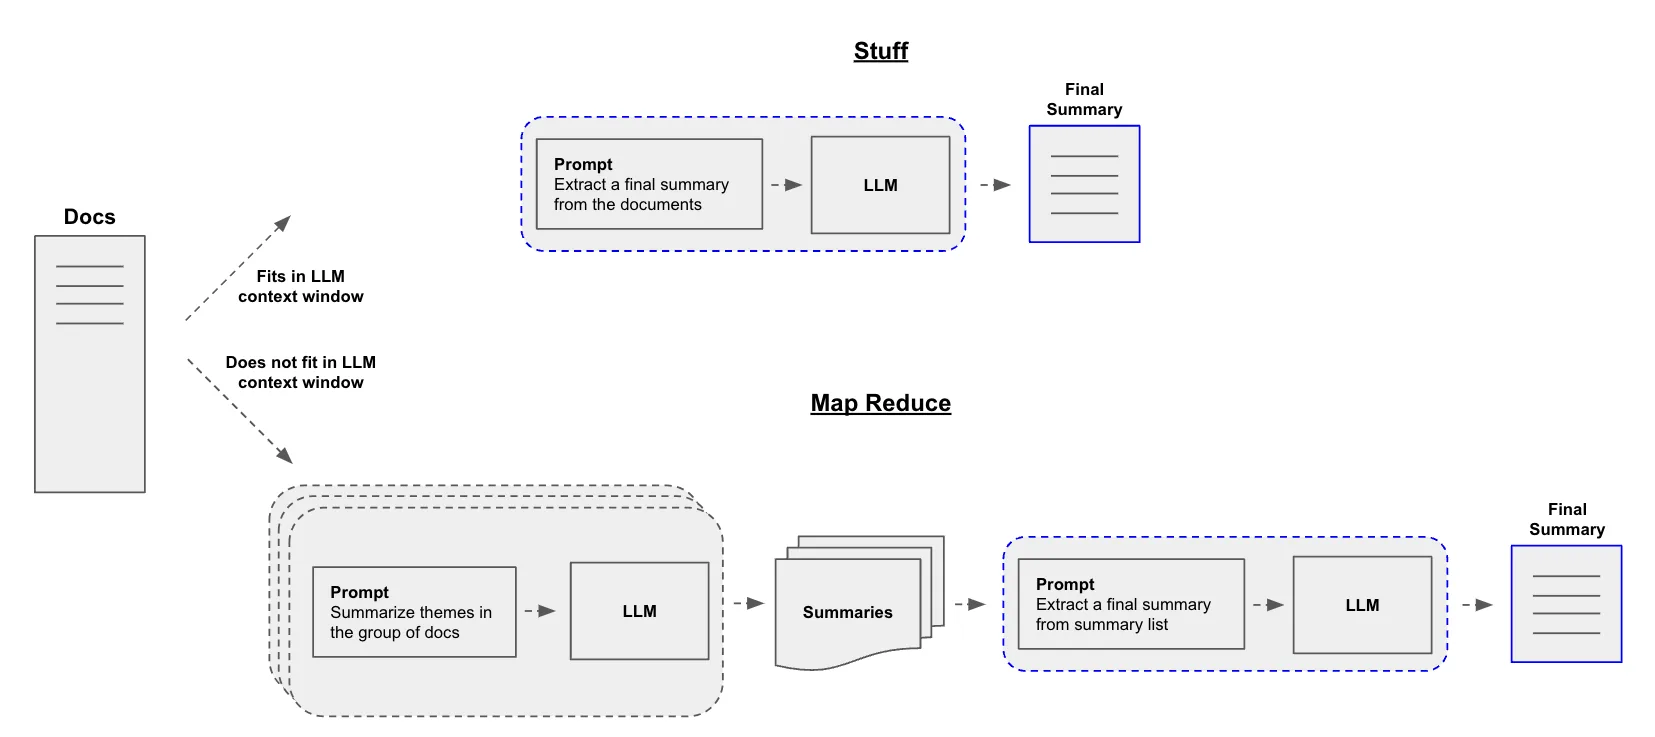

In [13]:
!pip install pypdf

In [27]:
# 데이터 로드하기
from langchain_community.document_loaders import PyPDFLoader

# 페이지별 Documents 객체 생성
loader = PyPDFLoader("SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
docs=docs[3:8] # 문서의 일부만 요약
print(f"총 페이지 수:{len(docs)}")


총 페이지 수:5


### Map

map 단계에서는 각 Chunk에 대한 요약을 생성합니다


In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini",
)

# map prompt 다운로드
map_prompt = client.pull_prompt("teddynote/map-prompt",
                                dangerously_pull_public_prompt=True)

# 프롬프트 출력
map_prompt.pretty_print()

================================ System Message ================================

You are a professional main thesis extractor.

================================ Human Message =================================

Your task is to extract main thesis from given documents. Answer should be in same language as given document. 

#Format: 
- thesis 1
- thesis 2
- thesis 3
- ...

Here is a given document: 
{doc}

Write 1~5 sentences.
#Answer:


In [29]:
# map_chain 생성
map_chain = map_prompt | llm | StrOutputParser()

In [30]:
# batch() 를 호출하여 각 문서에 대한 요약본을 생성

# 문서에 대한 주요내용 추출
doc_summaries=map_chain.batch(docs)

# 요약된 문서의 수 출력
len(doc_summaries)


5

In [31]:
# 일부 문서의 요약 출력
print(doc_summaries[0])

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제협력을 포함한 광범위한 내용을 담고 있다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 미국 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련될 예정이다.
- 또한, 중소기업과 개발자에게 기술과 인프라를 지원하고, 외국인 전문가들이 미국에서 공부하고 취업할 수 있도록 비자 기준을 현대화할 계획이다.


### Reduce 

Reduce 단계에서는 map 단계에서 진행한 핵심 내용들을 하나의 최종 요약으로 통합합니다.

In [32]:
# reduce prompt 다운로드
reduce_prompt = client.pull_prompt("teddynote/reduce-prompt",
                                   dangerously_pull_public_prompt=True)

# 프롬프트 출력
reduce_prompt.pretty_print()

================================ System Message ================================

You are a professional summarizer. You are given a list of summaries of documents and you are asked to create a single summary of the documents.

================================ Human Message =================================

#Instructions: 
1. Extract main points from a list of summaries of documents
2. Make final summaries in bullet points format.
3. Answer should be written in {language}.

#Format: 
- summary 1
- summary 2
- summary 3
- ...

Here is a list of summaries of documents: 
{doc_summaries}

#SUMMARY:


In [33]:
# Reduce Chain 생성
reduce_chain = reduce_prompt | llm | StrOutputParser()

from langchain_teddynote.messages import stream_response

answer = reduce_chain.stream({"doc_summaries": doc_summaries, "language": "Korean"})
stream_response(answer)

- 미국 바이든 대통령이 AI 개발과 사용의 안전성을 보장하기 위한 행정명령을 발표하였으며, AI 시스템 개발 기업은 안전 테스트 결과를 정부와 공유해야 한다.
- G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하고, AI의 위험 평가 및 투명성을 보장할 것을 요구하였다.
- 28개국이 AI 안전성 정상회의에서 블레츨리 선언을 발표하고, AI 안전 보장을 위한 협력의 중요성을 강조하였다.
- 미국 캘리포니아 북부지방법원은 생성 AI 기업에 대한 저작권 침해 소송을 기각하였으며, 원고 측에 고소장 수정을 요청하였다.
- 미국 연방거래위원회(FTC)는 생성 AI의 소비자 및 창작자에 대한 피해 가능성을 경고하고, 빅테크의 시장 지배력 강화 우려를 표명하였다.

## Map Prompt


In [ ]:
from langchain import hub
from langchain_core.prompts import PromptTemplate

prompt_title = "map-prompt"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt_template = """You are a helpful expert journalist in extracting the main themes from a GIVEN DOCUMENTS below.
Please provide a comprehensive summary of the GIVEN DOCUMENTS in numbered list format. 
The summary should cover all the key points and main ideas presented in the original text, while also condensing the information into a concise and easy-to-understand format. 
Please ensure that the summary includes relevant details and examples that support the main ideas, while avoiding any unnecessary information or repetition. 
The length of the summary should be appropriate for the length and complexity of the original text, providing a clear and accurate overview without omitting any important information.

GIVEN DOCUMENTS:
{docs}

FORMAT:
1. main theme 1
2. main theme 2
3. main theme 3
...

CAUTION:
- DO NOT list more than 5 main themes.

Helpful Answer:
"""
prompt = PromptTemplate.from_template(prompt_template)
prompt

### Map-Refine

Map-refine 방식은 문서 요약을 위한 또 다른 접근법으로, map-reduce와 유사하지만 약간의 차이가 있습니다.

1. Map 단계 : 문서를 여러 개의 작은 chunk로 나누고, 각 chunk에 대해 개별적으로 요약을 생성합니다.

2. Refine 단계 :  생성된 요약들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 
    각 단계에서 이전 요약과 새로운  chunk의 정보를 결합하여 요약을 갱신합니다.

3. 반복 과정 : 모든 chunk가 처리될 때까지 refine 단계를 반복합니다.

4. 최종 요약 : 마지막 chunk까지 처리한 후 얻은 요약이 최종 결과가 됩니다.

map-refine 방식의 장점은 문서의 순서를 유지하면서 점진적으로 요약을 개선할 수 있다는 것입니다.
이는 특히 문서의 맥락이 중요한 경우에 유용할 수 있습니다. 
그러나 이 방식은 map-reduce 에 비해 순차적으로 처리되기 때문에 병렬화가 어려워 대규모 문서 처리 시 시간이 더 오래 걸릴 수 있습니다.

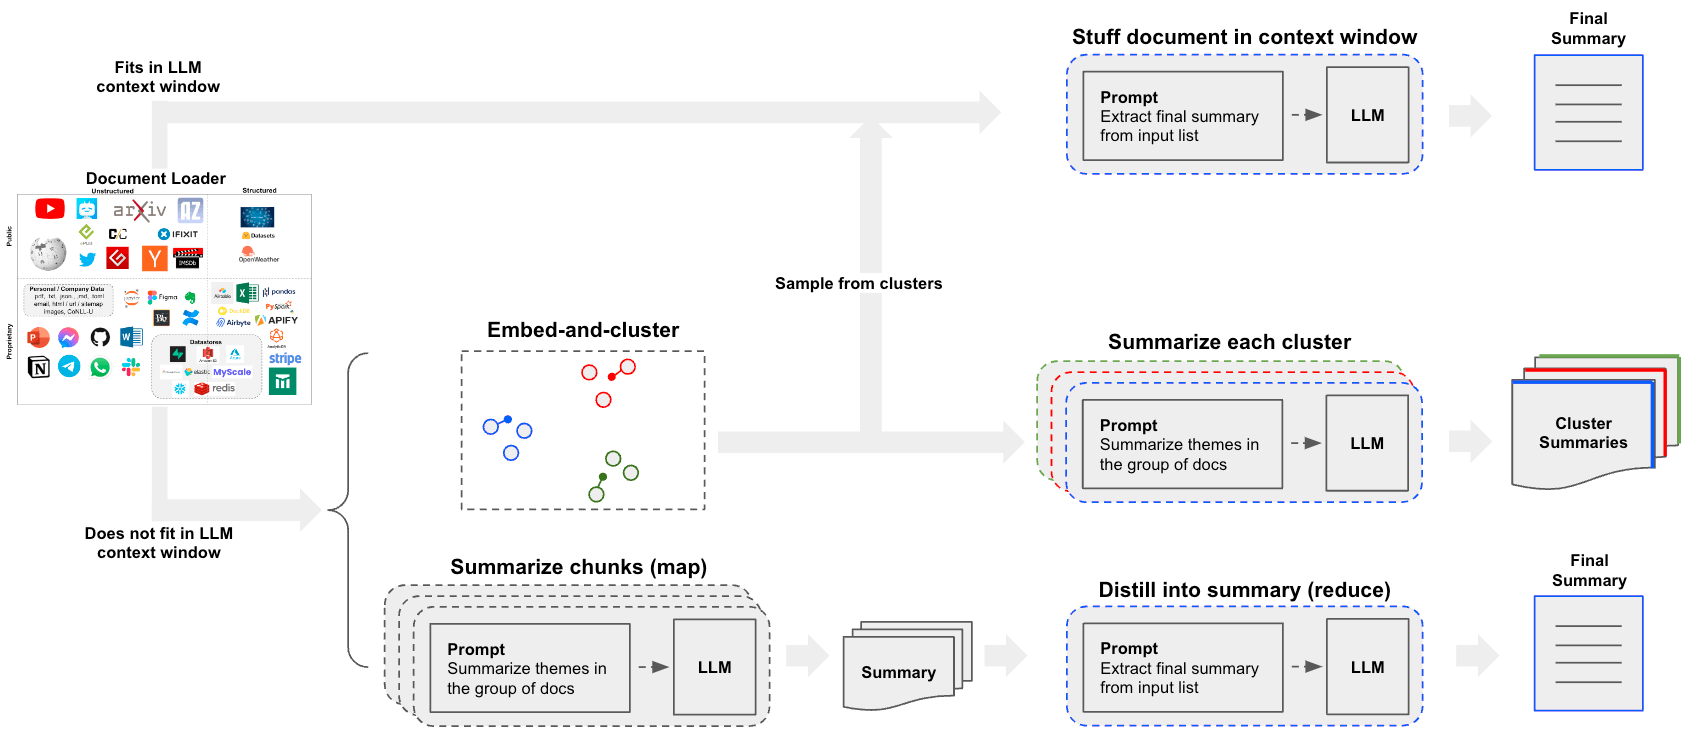

In [35]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# map llm 생성
map_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini",
)

# map chain 생성
map_summary = client.pull_prompt("teddynote/map-summary-prompt",
                                 dangerously_pull_public_prompt=True)

# 프롬프트 출력
map_summary.pretty_print()

================================ System Message ================================

You are an expert summarizer. Your task is to summarize the following document in {language}.

================================ Human Message =================================

Extract most important main thesis from the documents, then summarize in bullet points.

#Format:
- summary 1
- summary 2
- summary 3
-...

Here is a given document: 
{documents}

Write 1~5 sentences. Think step by step.
#Summary:


In [36]:
# map chain 생성
map_chain = map_summary | llm | StrOutputParser()

# 첫 번째 문서의 요약 출력
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.


In [37]:
# 모든 문서를 입력으로 정의합니다.
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]

# 모든 문서에 대한 요약본을 출력합니다.
print(map_chain.batch(input_doc))

['- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.\n- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.\n- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 지침이 마련된다.\n- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.\n- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.', "- G7은 2023년 10월 30일 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였다.\n- 이 행동강령은 AI 시스템의 위험 식별 및 완화를 위한 자발적인 채택을 권장하며, AI 수명주기 전반에 걸친 위험 평가와 투명성, 책임성을 강조한다.\n- 주요 내용으로는 정보 공유, 협력, 보안 통제, 콘텐츠 인증 및 출처 확인 메커니즘 개발 등이 포함된다.\n- G7은 기술 발전에 대응하기 위해 이해관계자 협의를 통해 행동강령을 필요에 따라 개정할 계획이다.\n- 또한, 사회적 위험 완화와 세계적 난제 해결을 위한 AI 시스템 개발을 우선시하고, 개인정보 보호를 위한 적절한 보호 장치를 구현할 것을 제안하였다.", '- 28개국이 영국 블레츨리 파크에서 열린 AI 안전성 정상회의에서 AI 안전 보장을 위한 블레츨리 선언을 발표했다.\n- 선언은 AI 시스템의 안전성을 보장하기 위해 모든 이해관계자의 협력이 필요하다고 강조하며, 특히 AI 개발 기업의 책임을 지적했다.\n- 영국 총리는 AI 안전 연구소의 출범과 함께 첨단 AI 모델에 대한 안전성 시험 계획을 발표하고, 각국 정부는 테스트 결과를 공유하고 공동 표준 개발을 위해 협력하기로 합의했다.\n- 참가국들은 AI 위험과 가능성에 대한 과학적 평가를 위한

### Refine

Refine 단계에서는 이전의 map 단계에서 생성한 chunk들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다.


In [38]:
# refine prompt 다운로드
refine_prompt = client.pull_prompt("teddynote/refine-prompt",
                                   dangerously_pull_public_prompt=True)

# 프롬프트 출력
refine_prompt.pretty_print()

================================ System Message ================================

You are an expert summarizer.

================================ Human Message =================================

Your job is to produce a final summary

We have provided an existing summary up to a certain point:
{previous_summary}

We have the opportunity to refine the existing summary(only if needed) with some more context below.
------------
{current_summary}
------------
Given the new context, refine the original summary in {language}.
If the context isn't useful, return the original summary.


In [39]:
# refine chain 생성
refine_chain = refine_prompt | llm | StrOutputParser()

In [14]:
from langchain_core.runnables import chain
from langchain_teddynote.callbacks import StreamingCallback


@chain
def map_refine_chain(docs):

    # map chain 생성
    map_summary = client.pull_prompt("teddynote/map-summary-prompt",
                                     dangerously_pull_public_prompt=True)

    map_chain = (
        map_summary
        | ChatOpenAI(
            model_name="gpt-4o-mini",
            temperature=0,
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = client.pull_prompt("teddynote/refine-prompt",
                                       dangerously_pull_public_prompt=True)

    refine_llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print("\n\n-----------------\n\n")

    return previous_summary


In [25]:
refined_summary = map_refine_chain.invoke(docs)


- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.
- 또한, G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였으며, 이는 AI 시스템의 위험 식별과 완화를 위한 자발적 채택을 권장하고, AI 수명주기 전반에 걸친 위험 평가와 투명성, 책임성을 강조한다.
- G7은 정보공유와 협력, 보안 통제, 콘텐츠 인증 및 출처 확인 메커니즘 개발 등을 주요 내용으로 포함하며, 사회적 위험 완화와 글로벌 문제 해결을 위한 AI 시스템 개발에 우선 투자할 것을 제안하였다.

-----------------


- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.
- G7은 '히로시마 AI 프로세스'

### Chain of Density(CoD)

- GPT-4를 사용한 요약 생성을 개선하기 위해 개발된 기법입니다.

초기에 개체가 적은 요약을 생성한 후, 길이를 늘리지 않으면서 누락된 중요 개체들을 반복적으로 통합하는 과정을 거칩니다. 연구 결과, CoD로 생성된 요약은 일반 프롬프트보다 더 추상적이고 정보 융합이 뛰어나며, 인간이 작성한 요약과 비슷한 밀도를 가진 것으로 나타났습니다.

원본 콘텐츠를 보고 llm 모델이 최초 요약을 생성하면 원본 콘텐츠와 현재 요약을 llm이 비교하여 중요하다고 판단한 엔티티 1~3개를 선택하여 기존 요약에 통합합니다. 이렇게 만들어진 새로운 요약을 다시 원본과 비교하여 다시 빠진 중요한 엔티티를 찾아 추가합니다. 반복하면서 같은 길이 안에서 density, 더 많은 핵심 정보를 담습니다.

1. 점진적 개선: CoD는 초기에 개체가 적은 간단한 요약을 생성한 후, 단계적으로 중요한 개체들을 추가하며 요약을 개선합니다. 이 과정에서 요약의 길이는 유지되면서 정보 밀도가 증가하여 읽기 쉬우면서도 정보량이 풍부한 요약이 만들어집니다.

2. 정보 밀도와 가독성의 균형 : CoD 방식은 요약의 정보 밀도를 조절하여 정보성과 가독성 사이의 최적 균형점을 찾습니다. 연구 결과에 따르면, 사람들은 일반적인 GPT-4 요약보다 더 밀도 있지만 사람이 작성한 요약만큼 밀도가 높지 않은 CoD 요약을 선호하는 것으로 나타났습니다.

3. 추상화와 정보 융합 개선: CoD로 생성된 요약은 더 추상적이고 정보 융합이 뛰어나며, 원문의 앞부분에 치우치는 경향(lead bias)이 덜합니다. 이는 요약의 전반적인 품질과 가독성을 향상시키는데 기여합니다.

CoD Prompt 입력 파라미터 설명

- `content_category`: 콘텐츠 정류(예: 기사, 동영상 녹취록, 블로그 게시물,연구 논문). 기본값: Article
- `content`: 요약할 컨텐츠
- `entity_range`: 콘텐츠(원본)에서 선택하여 요약에 추가할 엔티티 수의 범위. 기본값은 1-3개(한 번의 반복에)
    llm이 콘텐츠를 읽고, 그 중 요약에 추가하면 좋을 1~3개 중요 엔티티(정보)를 선택해서 기존 요약에 통합
- `max_words`: 1번 요약시, 요약에 포함할 최대 단어. 기본값은 80입니다.
- `iterations`:엔티티 고밀도화 라운드 수. 총 요약은 `반복횟수+1`입니다. 80단어의 경우 3회 반복이 이상적입니다. 요약이 더 길면 4~5회, 그리고 `entity_range`를 예를 들어 1~4로 변경하는 것도 도움이 될 수 있습니다. 기본값:3 / 이 코드는 CoD 프롬프트를 사용하여 텍스트 요약을 생성하는 체인을 구성합니다.

In [41]:
import textwrap
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import SimpleJsonOutputParser

client = Client()

# {content}를 제외한 모든 입력에 대한 기본값 지정
cod_chain_inputs={
    "content":lambda d:d.get("content"),
    "content_category":lambda d: d.get("content_category","Article"),
    "entity_range":lambda d:d.get("entity_range","1-3"),
    "max_words":lambda d:int(d.get("max_words",80)),
    "iterations":lambda d:int(d.get("iterations",5)),


}

#Chain of Density 프롬프트 다운로드
cod_prompt = client.pull_prompt("teddynote/chain-of-density-prompt",
                                dangerously_pull_public_prompt=True)

# Chain of Density 체인 생성, 첫 번째 체인은 중간 결과를 보여주고, 두 번째 체인은 최종 요약만을 추출합니다.
cod_chain = (
    cod_chain_inputs | cod_prompt | ChatOpenAI(temperature=0,model="gpt-4o-mini") |SimpleJsonOutputParser()
)

# 두 번째 체인 생성, 최종 요약만 추출(스트리밍 불가능, 최종 결과가 필요함)
cod_final_summary_chain=cod_chain | (
    lambda output:output[-1].get(
        "denser_summary",'오류:마지막 딕셔너리에 "denser_summary" 키가 없습니다.'
    )
    
)

In [42]:
# 요약할 데이터를 확인
content = docs[1].page_content
print(content)

SPRi AI Brief |  
2023-12월호
2
G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의
n G7이 첨단 AI 시스템을 개발하는 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 
채택을 권고하는 AI 국제 행동강령을 마련
n 행동강령은 AI 수명주기 전반에 걸친 위험 평가와 완화, 투명성과 책임성의 보장, 정보공유와 
이해관계자 간 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등의 조치를 요구
KEY Contents
£ G7, 첨단 AI 시스템의 위험 관리를 위한 국제 행동강령 마련
n 주요 7개국(G7)*은 2023년 10월 30일 ‘히로시마 AI 프로세스’를 통해 AI 기업 대상의 AI 국제 
행동강령(International Code of Conduct for Advanced AI Systems)에 합의
∙ G7은 2023년 5월 일본 히로시마에서 개최된 정상회의에서 생성 AI에 관한 국제규범 마련과 
정보공유를 위해 ‘히로시마 AI 프로세스’를 출범**
∙ 기업의 자발적 채택을 위해 마련된 이번 행동강령은 기반모델과 생성 AI를 포함한 첨단 AI 시스템의 
위험 식별과 완화에 필요한 조치를 포함
* 주요 7개국(G7)은 미국, 일본, 독일, 영국, 프랑스, 이탈리아, 캐나다를 의미
** 5월 정상회의에는 한국, 호주, 베트남 등을 포함한 8개국이 초청을 받았으나, AI 국제 행동강령에는 우선 G7 국가만 포함하여 채택
n G7은 행동강령을 통해 아래의 조치를 제시했으며, 빠르게 발전하는 기술에 대응할 수 있도록 
이해관계자 협의를 통해 필요에 따라 개정할 예정
∙ 첨단 AI 시스템의 개발 과정에서 AI 수명주기 전반에 걸쳐 위험을 평가 및 완화하는 조치를 채택하고, 
첨단 AI 시스템의 출시와 배포 이후 취약점과 오용 사고, 오용 유형을 파악해 완화
∙ 첨단 AI 시스템의 성능과 한계를 공개하고 적절하거나 부적절한 사용영역을 알리는 방법으로 투명성을 
보장하고 책임성을 강화
∙ 산업계, 정부, 시민사회, 학

JSON은 llm 단계별 결과를 구조적으로 주고받게 하기 위한 출력 형식입니다.

부분 JSON 스트리밍하기. 스트리밍된 각 청크는 새로운 접미사가 추가된 동일한 JSON 딕트 목록입니다.

따라서 단순히 연결하는 것이 아니라 다음 청크가 이전 청크를 덮어쓰고 반복적으로 스트리밍을 추가하는 것처럼 보이게 하려면 `\r` 캐리지 리턴 인쇄가 필요합니다.

In [43]:
# 결과를 저장할 빈 리스트 초기화
# 리스트 안의 각 원소가 키,값 모두 문자열인 딕셔너리
# result는 json 형식
results:list[dict[str,str]]=[]

# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content":content,"content_category":"Article"}
):
    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력(캐리지 리턴을 사용하여 이전 출력을 덮어씀) -> 마지막 결과만 표시
    # flush=True -> 결과 버퍼에 쌓아두지 말고 즉시 출력
    print(results,end="\r",flush=True)

# 총 요약 수 계산
total_summaries=len(results)
print("\n")

# 각 요약을 순회하며 처리
i=1
for cod in results:
    # 누락된 엔티티들을 추출하고 포맷팅
    added_entities=",".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities",'ERR:"missing_entities" key not found'
            ).split(';')
        ]
    )
    # 더 밀도 있는 요약 추출
    summary=cod.get("denser_summary",'ERR:missing_key"denser_summary"')

    # 요약 정보 출력(번호, 총 개수, 추가된 엔티티)
    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity):{added_entities}"
        +"\n"
    )
    # 요약된 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary,width=80)+"\n")
    i += 1
    
print("\n=====================[최종 요약]================\n")


[{'missing_entities': 'G7;히로시마 AI 프로세스;AI 국제 행동강령', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 책임성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': '위험 평가;투명성;정보공유', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, 위험 평가, 투명성, 책임성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': 'AI 수명주기;보안 통제;콘텐츠 인증', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': 'AI 위험;AI 거버넌스;위험 관리', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 정보공유, 보안 통제, AI 거버넌스 및 위험 관리 조치를 요구한다.'}, {'missing_entities': '사회적 위험;기후 위기;세계적 난제', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세

In [17]:
print(summary)

G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 첨단 AI 시스템의 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 국제 기술 표준 개발, 데이터 보호, 신뢰할 수 있는 콘텐츠 인증, 사회적 위험 완화 조치를 포함한 조치를 요구한다.


### Clustering-Map-Refine

각 문서들을 embedding해서 벡터 좌표를 구함

1. mao-reduce나 map-refine 방식은 모두 시간이 오래 걸리고, 비용이 많이 듬.
2. 따라서 문서를 몇 개(N개)의 클러스터로 나눈 뒤, 가장 중심축에서 가까운 문서를 클러스터의 대표 문서로 인지하고, 이를 map-reduce(혹은 map-refine) 방식으로 요약하는 방식을 제안

In [19]:
!pip install pymupdf

   ---------------------------------------- 0.0/19.8 MB ? eta -:--:--
   -- ------------------------------------- 1.3/19.8 MB 11.2 MB/s eta 0:00:02
   ------ --------------------------------- 3.4/19.8 MB 10.1 MB/s eta 0:00:02
   ----------- ---------------------------- 5.5/19.8 MB 9.9 MB/s eta 0:00:02
   -------------- ------------------------- 7.3/19.8 MB 9.6 MB/s eta 0:00:02
   ------------------- -------------------- 9.4/19.8 MB 9.6 MB/s eta 0:00:02
   --------------------- ------------------ 10.7/19.8 MB 9.1 MB/s eta 0:00:02
   ----------------------- ---------------- 11.8/19.8 MB 8.5 MB/s eta 0:00:01
   ------------------------- -------------- 12.8/19.8 MB 8.1 MB/s eta 0:00:01
   ----------------------------- ---------- 14.7/19.8 MB 8.1 MB/s eta 0:00:01
   ------------------------------- -------- 15.7/19.8 MB 7.9 MB/s eta 0:00:01
   ---------------------------------- ----- 17.0/19.8 MB 7.8 MB/s eta 0:00:01
   ------------------------------------- -- 18.4/19.8 MB 7.6 MB/s eta 0:00:

In [1]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("SPRI_AI_Brief_2023년12월호_F.pdf")
docs=loader.load()

len(docs)

C:\Users\HAN\AppData\Local\Temp\ipykernel_20008\1714109659.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


23

In [2]:
# 하나의 문서로 텍스트를 합침. 합치는 목적은 page 별로 구분하지 않기 위해서입니다.
texts="\n\n".join([doc.page_content for doc in docs])
len(texts)

27977

In [3]:
# RecursiveCharacterTextSplitter를 사용하여 하나의 Text를 여러 문서로 나눕니다.
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 문장이 청크의 경계에서 잘리는 문제를 줄이기 위해 앞 청크의 마지막 100 글자 포함
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
split_docs=text_splitter.split_text(texts)

In [4]:
# 총 문서의 수 확인
len(split_docs)

79

In [ ]:
#! pip install langchain_upstage

In [4]:
# .env에 파일에 저장된 환경 변수 불러오기
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
# Upstage Embeddings 모델을 사용하여 문서를 임베딩
from langchain_upstage import UpstageEmbeddings

embeddings=UpstageEmbeddings(model="solar-embedding-1-large-passage")

vectors=embeddings.embed_documents(split_docs)

In [6]:
# 총 79개의 문서를 10개 클러스터로 나눕니다. 이때 `KMeans`를 사용하여 클러스터링을 수행합니다.

from sklearn.cluster import KMeans

# 클러스터 수를 선택하면 문서의 콘텐츠에 따라 조정할 수 있습니다.
num_clusters=10

#Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters,random_state=123).fit(vectors)

In [7]:
import pandas as pd
pd.Series(kmeans.labels_).value_counts()

4    13
8    13
3    11
9     8
5     7
1     7
6     6
7     5
2     5
0     4
Name: count, dtype: int64

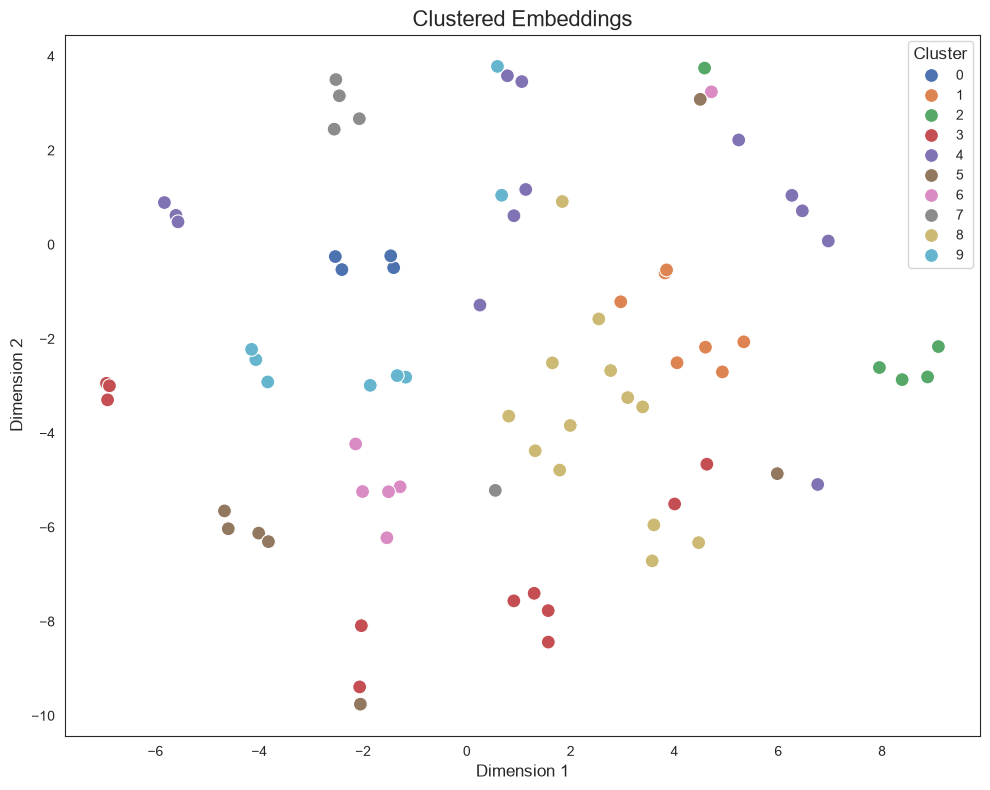

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 경고 제거
import warnings

warnings.filterwarnings("ignore")

# t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

# seaborn 스타일 설정
sns.set_style("white")

# 축소된 데이터 플롯
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

# 배경색 설정
plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()


In [10]:
# 각 cluster의 중심점에 가장 가까운 임베딩을 찾아서 저장
import numpy as np

# 가장 가까운 점들을 저장할 빈 리스트 생성
closest_indices = []

# 클러스터 수만큼 반복
for i in range(num_clusters):

    # 해당 클러스터 중심으로부터의 거리 목록 구하기
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # 가장 가까운 점의 인덱스 찾기 (argmin을 사용하여 최소 거리 찾기)
    closest_index = np.argmin(distances)

    # 해당 인덱스를 가장 가까운 인덱스 리스트에 추가
    closest_indices.append(closest_index)


In [11]:
# 문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬
selected_indices = sorted(closest_indices)
selected_indices


[4, 16, 24, 28, 34, 37, 41, 47, 51, 55]

In [12]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs


[Document(metadata={}, page_content='▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망································ 13\n   ▹ 유튜브, 2024년부터 AI 생성 콘텐츠 표시 의무화···························································· 14\n 3. 기술/연구\n   ▹ 영국 과학혁신기술부, AI 안전 연구소 설립 발표······························································ 15\n   ▹ 구글 딥마인드, 범용 AI 모델의 기능과 동작에 대한 분류 체계 발표······························ 16\n   ▹ 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수 ··········································· 17\n   \n 4. 인력/교육'),
 Document(metadata={}, page_content='1. 정책/법제  \n2. 기업/산업 \n3. 기술/연구 \n 4. 인력/교육\n영국 AI 안전성 정상회의에 참가한 28개국, AI 위험에 공동 대응 선언\nn 영국 블레츨리 파크에서 개최된 AI 안전성 정상회의에 참가한 28개국들이 AI 안전 보장을 \n위한 협력 방안을 담은 블레츨리 선언을 발표\nn 첨단 AI를 개발하는 국가와 기업들은 AI 시스템에 대한 안전 테스트 계획에 합의했으며, \n영국의 AI 안전 연구소가 전 세계 국가와 협력해 테스트를 주도할 예정 \nKEY Contents\n£ AI 안전성 정상회의 참가국들, 블레츨리 선언 통해 AI 안전 보장을 위한 협력에 합의\nn 2023년 11월 1~2일 영국 블레츨리 파크에서 열린 AI 안전성 정상회의(AI Safety Summit)에 \n참가한 28개국 대표들이 AI 위험 관리를 위한 ‘블레츨리 선언’을 발표 \n∙선언은 AI 안전 보장을 위해 

In [20]:
# 이전에 생성한 map_refine_chain을 사용하여 요약 생성
refined_summary = map_refine_chain.invoke(selected_docs)


- 빌 게이츠는 AI 에이전트가 컴퓨터 사용의 패러다임을 변화시킬 것이라고 전망했다.
- 유튜브는 2024년부터 AI 생성 콘텐츠에 대한 표시를 의무화할 예정이다.
- 영국 과학혁신기술부는 AI 안전 연구소를 설립한다고 발표했다.
- 28개국이 참가한 영국 AI 안전성 정상회의에서 AI 위험에 대한 공동 대응을 위한 블레츨리 선언이 발표되었다. 이 선언은 AI 안전 보장을 위해 모든 이해관계자의 협력을 강조하고 있다.
- 첨단 AI 개발 국가와 기업들은 AI 시스템에 대한 안전 테스트 계획에 합의하였으며, 영국의 AI 안전 연구소가 이를 주도할 예정이다.
- 구글 딥마인드는 범용 AI 모델의 기능과 동작에 대한 새로운 분류 체계를 발표했다.
- 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수한 성능을 보였다.

-----------------


- 빌 게이츠는 AI 에이전트가 컴퓨터 사용의 패러다임을 변화시킬 것이라고 전망했다.
- 유튜브는 2024년부터 AI 생성 콘텐츠에 대한 표시를 의무화할 예정이다.
- 영국 과학혁신기술부는 AI 안전 연구소를 설립한다고 발표했다.
- 28개국이 참가한 영국 AI 안전성 정상회의에서 AI 위험에 대한 공동 대응을 위한 블레츨리 선언이 발표되었다. 이 선언은 AI 안전 보장을 위해 모든 이해관계자의 협력을 강조하고 있다.
- 첨단 AI 개발 국가와 기업들은 AI 시스템에 대한 안전 테스트 계획에 합의하였으며, 영국의 AI 안전 연구소가 이를 주도할 예정이다.
- 구글 딥마인드는 범용 AI 모델의 기능과 동작에 대한 새로운 분류 체계를 발표했다.
- 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수한 성능을 보였다.
- 미국 연방거래위원회(FTC)는 저작권청에 AI와 관련된 소비자 보호 및 경쟁 측면의 의견서를 제출하며, 생성 AI로 인해 창작자와 소비자에게 피해가 발생할 가능성에 대해 우려를 표명했다. 
- FTC는 일부 대형 기술 기업들이 막대한 자원을 통해 시장 지배력을 강화할 수 있다는 점에 

In [21]:
# 최종 결과 출력
print(refined_summary)

- 빌 게이츠는 5년 내에 일상 언어로 모든 작업을 처리할 수 있는 AI 에이전트가 보급될 것이라고 전망하며, 이러한 AI 에이전트가 컴퓨터 사용 방식을 완전히 변화시키고 소프트웨어 산업에도 큰 영향을 미칠 것으로 예상하고 있다. 이 기술은 자연어에 반응하고 사용자에 대한 지식을 바탕으로 다양한 작업을 수행하는 소프트웨어를 포함하며, 의료, 교육, 생산성, 엔터테인먼트 및 쇼핑 등 다양한 산업 분야에 걸쳐 고가의 서비스를 대중화할 것으로 보인다.
- 유튜브는 2024년부터 AI 생성 콘텐츠에 대한 표시를 의무화할 예정이다.
- 영국 과학혁신기술부는 AI 안전 연구소를 설립한다고 발표했다.
- 28개국이 참가한 영국 AI 안전성 정상회의에서 AI 위험에 대한 공동 대응을 위한 블레츨리 선언이 발표되었으며, 이 선언은 AI 안전 보장을 위해 모든 이해관계자의 협력을 강조하고 있다.
- 첨단 AI 개발 국가와 기업들은 AI 시스템에 대한 안전 테스트 계획에 합의하였으며, 영국의 AI 안전 연구소가 이를 주도할 예정이다.
- 구글 딥마인드는 범용 AI 모델의 기능과 동작에 대한 새로운 분류 체계를 발표했다.
- 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수한 성능을 보였다.
- 미국 연방거래위원회(FTC)는 저작권청에 AI와 관련된 소비자 보호 및 경쟁 측면의 의견서를 제출하며, 생성 AI로 인해 창작자와 소비자에게 피해가 발생할 가능성에 대해 우려를 표명했다. FTC는 일부 대형 기술 기업들이 막대한 자원을 통해 시장 지배력을 강화할 수 있다는 점에 대한 우려도 제기했다.
- 저작권청은 생성 AI와 관련된 저작권법 및 정책 이슈를 조사하고 있으며, 폭넓은 의견 수렴을 진행 중이다.
- EU의 AI 법 최종협상에서 프랑스, 이탈리아, 독일이 기반모델 규제에 반대하며 협상이 어려움을 겪고 있다. 이들 국가는 기반모델 개발기업에 자율적 행동강령을 도입하고 이를 의무화하는 방안을 제안하였다.
- 10월 24일 회의에서는 강력한 AI 모델에 대해 더 엄격한 규

## Reduce Prompt


In [ ]:
from langchain import hub
from langchain.prompts import PromptTemplate

prompt_title = "reduce-prompt"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt_template = """You are a helpful expert in summary writing.
You are given numbered lists of summaries.
Extract top 10 most important insights from the summaries.
Then, write a summary of the insights in KOREAN.

LIST OF SUMMARIES:
{doc_summaries}

Helpful Answer:
"""
prompt = PromptTemplate.from_template(prompt_template)
prompt

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt)

In [ ]:
from langchain import hub
from langchain.prompts import PromptTemplate

prompt_title = "chain-of-density-reduce-korean"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt_template = """You are a helpful expert in summary writing. You are given lists of summaries.
Please sum up previously summarized sentences according to the following REQUEST.
REQUEST:
1. Summarize the main points in bullet points in KOREAN.
2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.
3. Use various emojis to make the summary more interesting.
4. MOST IMPORTANT points should be organized at the top of the list.
5. DO NOT include any unnecessary information.

LIST OF SUMMARIES:
{doc_summaries}

Helpful Answer: """
prompt = PromptTemplate.from_template(prompt_template)
prompt

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt)

## Metadata Tagger


In [ ]:
from langchain import hub
from langchain.prompts import ChatPromptTemplate

prompt_title = "metadata-tagger"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt_template = """Given the following product review, conduct a comprehensive analysis to extract key aspects mentioned by the customer, with a focus on evaluating the product's design and distinguishing between positive aspects and areas for improvement. 
Identify primary features or attributes of the product that the customer appreciated or highlighted, specifically looking for mentions related to the feel of the keys, sound produced by the keys, overall user experience, charging aspect, and the design of the product, etc. 
Assess the overall tone of the review (positive, neutral, or negative) based on the sentiment expressed about these attributes. 
Additionally, provide a detailed evaluation of the design, outline the positive aspects that the customer enjoyed, and note any areas of improvement or disappointment mentioned. 
Extract the customer's rating of the product on a scale of 1 to 5, as indicated at the beginning of the review. 
Summarize your findings in a structured JSON format, including an array of keywords, evaluations for design, satisfaction points, improvement areas, the assessed tone, and the numerical rating. 

INPUT:
{input}

"""
prompt = ChatPromptTemplate.from_template(prompt_template)
prompt

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt)

## Chain of Density 요약

In [ ]:
from langchain import hub
from langchain.prompts import ChatPromptTemplate

prompt_title = "chain-of-density-korean"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt = ChatPromptTemplate.from_template(
    """Article: {ARTICLE}
You will generate increasingly concise, entity-dense summaries of the above article. 

Repeat the following 2 steps 5 times. 

Step 1. Identify 1-3 informative entities (";" delimited) from the article which are missing from the previously generated summary. 
Step 2. Write a new, denser summary of identical length which covers every entity and detail from the previous summary plus the missing entities. 

A missing entity is:
- relevant to the main story, 
- specific yet concise (100 words or fewer), 
- novel (not in the previous summary), 
- faithful (present in the article), 
- anywhere (can be located anywhere in the article).

Guidelines:

- The first summary should be long (8-10 sentences, ~200 words) yet highly non-specific, containing little information beyond the entities marked as missing. Use overly verbose language and fillers (e.g., "this article discusses") to reach ~200 words.
- Make every word count: rewrite the previous summary to improve flow and make space for additional entities.
- Make space with fusion, compression, and removal of uninformative phrases like "the article discusses".
- The summaries should become highly dense and concise yet self-contained, i.e., easily understood without the article. 
- Missing entities can appear anywhere in the new summary.
- Never drop entities from the previous summary. If space cannot be made, add fewer new entities. 

Remember, use the exact same number of words for each summary.
Answer in JSON. The JSON should be a list (length 5) of dictionaries whose keys are "Missing_Entities" and "Denser_Summary".
Use only KOREAN language to reply."""
)

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt)

## Chain of Density (Korean) - 2


In [ ]:
from langchain import hub
from langchain.prompts import ChatPromptTemplate

prompt_title = "chain-of-density-map-korean"

# 요약문을 작성하기 위한 프롬프트 정의 (직접 프롬프트를 작성하는 경우)
prompt = ChatPromptTemplate.from_template(
    """Article: {ARTICLE}
You will generate increasingly concise, entity-dense summaries of the above article. 

Repeat the following 2 steps 3 times. 

Step 1. Identify 1-3 informative entities (";" delimited) from the article which are missing from the previously generated summary. 
Step 2. Write a new, denser summary of identical length which covers every entity and detail from the previous summary plus the missing entities. 

A missing entity is:
- relevant to the main story, 
- specific yet concise (100 words or fewer), 
- novel (not in the previous summary), 
- faithful (present in the article), 
- anywhere (can be located anywhere in the article).

Guidelines:

- The first summary should be long (8-10 sentences, ~200 words) yet highly non-specific, containing little information beyond the entities marked as missing. Use overly verbose language and fillers (e.g., "this article discusses") to reach ~200 words.
- Make every word count: rewrite the previous summary to improve flow and make space for additional entities.
- Make space with fusion, compression, and removal of uninformative phrases like "the article discusses".
- The summaries should become highly dense and concise yet self-contained, i.e., easily understood without the article. 
- Missing entities can appear anywhere in the new summary.
- Never drop entities from the previous summary. If space cannot be made, add fewer new entities. 

Remember, use the exact same number of words for each summary.
Answer "Missing Entities" and "Denser_Summary" as in TEXT format.
Use only KOREAN language to reply."""
)

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt)

## RAG 문서 프롬프트

In [ ]:
prompt_title = "rag-korean"

In [ ]:
system = """당신은 질문-답변(Question-Answering)을 수행하는 친절한 AI 어시스턴트입니다. 당신의 임무는 주어진 문맥(context) 에서 주어진 질문(question) 에 답하는 것입니다.
검색된 다음 문맥(context) 을 사용하여 질문(question) 에 답하세요. 만약, 주어진 문맥(context) 에서 답을 찾을 수 없다면, 답을 모른다면 `주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다` 라고 답하세요.
기술적인 용어나 이름은 번역하지 않고 그대로 사용해 주세요. 답변은 한글로 답변해 주세요."""

human = """#Question: 
{question} 

#Context: 
{context} 

#Answer:"""

from langchain.prompts import ChatPromptTemplate


prompt = ChatPromptTemplate.from_messages([("system", system), ("human", human)])

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt, parent_commit_hash="latest")

## RAG + 출처

In [ ]:
from langchain import hub
from langchain.prompts import ChatPromptTemplate

In [ ]:
prompt_title = "rag-korean-with-source"

In [ ]:
system = """당신은 질문-답변(Question-Answering)을 수행하는 친절한 AI 어시스턴트입니다. 당신의 임무는 주어진 문맥(context) 에서 주어진 질문(question) 에 답하는 것입니다.
검색된 다음 문맥(context) 을 사용하여 질문(question) 에 답하세요. 만약, 주어진 문맥(context) 에서 답을 찾을 수 없다면, 답을 모른다면 `주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다` 라고 답하세요.
기술적인 용어나 이름은 번역하지 않고 그대로 사용해 주세요. 출처(page, source)를 답변헤 포함하세요. 답변은 한글로 답변해 주세요."""

human = """#Question: 
{question} 

#Context: 
{context} 

#Answer:"""

prompt = ChatPromptTemplate.from_messages([("system", system), ("human", human)])

In [ ]:
hub.push(f"{PROMPT_OWNER}/{prompt_title}", prompt, parent_commit_hash="latest")

## LLM Evaluation

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain import hub

prompt = PromptTemplate.from_template(
    """
As an LLM evaluator (judge), please assess the LLM's response to the given question. Evaluate the response's accuracy, comprehensiveness, and context precision based on the provided context. After your evaluation, return only the numerical scores in the following format:
Accuracy: [score]
Comprehensiveness: [score]
Context Precision: [score]
Final: [normalized score]
Grading rubric:

Accuracy (0-10 points):
Evaluate how well the answer aligns with the information provided in the given context.

0 points: The answer is completely inaccurate or contradicts the provided context
4 points: The answer partially aligns with the context but contains significant inaccuracies
7 points: The answer mostly aligns with the context but has minor inaccuracies or omissions
10 points: The answer fully aligns with the provided context and is completely accurate


Comprehensiveness (0-10 points):

0 points: The answer is completely inadequate or irrelevant
3 points: The answer is accurate but too brief to fully address the question
7 points: The answer covers main aspects but lacks detail or misses minor points
10 points: The answer comprehensively covers all aspects of the question


Context Precision (0-10 points):
Evaluate how precisely the answer uses the information from the provided context.

0 points: The answer doesn't use any information from the context or uses it entirely incorrectly
4 points: The answer uses some information from the context but with significant misinterpretations
7 points: The answer uses most of the relevant context information correctly but with minor misinterpretations
10 points: The answer precisely and correctly uses all relevant information from the context


Final Normalized Score:
Calculate by summing the scores for accuracy, comprehensiveness, and context precision, then dividing by 30 to get a score between 0 and 1.
Formula: (Accuracy + Comprehensiveness + Context Precision) / 30

#Given question:
{question}

#LLM's response:
{answer}

#Provided context:
{context}

Please evaluate the LLM's response according to the criteria above. 

In your output, include only the numerical scores for FINAL NORMALIZED SCORE without any additional explanation or reasoning.
ex) 0.81

#Final Normalized Score(Just the number):

"""
)

hub.push(f"teddynote/context-answer-evaluator", prompt)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# 프롬프트
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic m   eaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {context} \n\n User question: {question}"),
    ]
)

hub.push(f"teddynote/retrieval-question-grader", grade_prompt)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# Prompt
system = """You are a grader assessing relevance of a retrieved document to the answer. \n 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the answer, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the answer."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {context} \n\n Answer: {answer}"),
    ]
)

hub.push(f"teddynote/retrieval-answer-grader", grade_prompt)